In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from causal_mp import mp_causal_density
from causal_mp_iv import mp_density_iv

## Motivating Example

In [ ]:
from scipy.stats import norm, lognorm

# --- Parameters ---
mu = 10          # The common mean
sigma_0 = 2.0    # SD for control
x = np.linspace(mu - 8, mu + 8, 1000) # Slightly wider range for the tail

# 1. Polarization Parameters
delta = 3
sigma_sub = 1.2

# 2. Lottery Parameters
s = 0.7  # Shape parameter (skewness)
# For a Lognormal with scale=1, mean is exp(s^2 / 2). 
# To shift the mean to 'mu', we set loc = mu - exp(s^2 / 2)
loc_shift = mu - np.exp(s**2 / 2)

# --- Calculate PDFs ---

# Shared Control PDF
pdf_y0 = norm.pdf(x, mu, sigma_0)

# Left: Polarization Treatment (Mixture)
pdf_y1_pol = 0.5 * norm.pdf(x, mu - delta, sigma_sub) + 0.5 * norm.pdf(x, mu + delta, sigma_sub)

# Right: Lottery Treatment (Shifted Log-Normal)
target_mean = 10
x_b = np.linspace(0, 35, 1000) # Longer tail for lottery

# Control: Lower skewness
s0 = 0.3
mu0 = np.log(target_mean) - (s0**2 / 2)
pdf_y0_b = lognorm.pdf(x_b, s0, scale=np.exp(mu0))
# Treatment: Higher skewness
s1 = 0.8
mu1 = np.log(target_mean) - (s1**2 / 2)
pdf_y1_b = lognorm.pdf(x_b, s1, scale=np.exp(mu1))


# --- Plotting ---
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

# Panel A: Polarization
ax1.plot(x, pdf_y0, label='Control', lw=2)
ax1.plot(x, pdf_y1_pol, label='Treatment', lw=2)
ax1.set_xlabel("Outcome")
ax1.set_ylabel("Density")


# Panel B: Lottery
ax2.plot(x_b, pdf_y0_b, label='Control', lw=2)
ax2.plot(x_b, pdf_y1_b, label='Treatment', lw=2)
ax2.set_xlabel("Outcome")
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig("Figures/Motivating_Example.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Unconfounded with multiple covariates (Simulation 1, J = 2)

Replicates Simulation 1 with strong confounding (J = 2) from Xu et al. (2022, [arXiv:2211.01591](https://arxiv.org/abs/2211.01591)). Each subject has 5 covariates $X_j \sim U(-2, 2)$, of which the first two are confounders that drive the propensity score $T \mid X \sim \mathrm{Bern}(\mathrm{expit}(2(X_1 + X_2)))$. The control potential outcome $Y(0)$ is right-skewed and the treated potential outcome $Y(1)$ is bimodal; both depend on all five covariates. We estimate the marginal counterfactual densities $f_t(y)$ on a single realisation ($n = 500$) and compare three variants of our method: **S-Learner + Bayesian-bootstrap** treatment model, **S-Learner + logistic** treatment model, and **T-Learner + Bayesian bootstrap**, against the ground truth.

In [38]:
from scipy.stats import norm

# Simulation 1 (J = 2) from Xu et al. (2022), arXiv:2211.01591.
# 5 covariates ~ U(-2, 2); the first J are confounders driving the propensity score.
# Y(0) is right-skewed; Y(1) is a bimodal mixture of normals.

def _expit(a):
    return 1.0 / (1.0 + np.exp(-a))

def _Z(X, k):
    # Z_k = expit(0.8 * sum_j X_j + 0.1 * sum_j |X_j|^k)
    return _expit(0.8 * X.sum(axis=1) + 0.1 * (np.abs(X) ** k).sum(axis=1))

def _eps_pdf(e):
    # eps ~ 0.75 * N+(0, 0.9^2) + 0.25 * N-(0, 0.3^2)  (truncated half-normals)
    pos = 0.75 * 2.0 * norm.pdf(e, 0.0, 0.9) * (e >= 0)
    neg = 0.25 * 2.0 * norm.pdf(e, 0.0, 0.3) * (e < 0)
    return pos + neg

def generate_data_sim1(n, J=2, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, size=(n, 5))
    ps = _expit((4.0 / J) * X[:, :J].sum(axis=1))
    Tr = (rng.uniform(size=n) < ps).astype(int)

    Z1 = _Z(X, 1)
    Z2 = _Z(X, 2)

    # Y(0): -2.3 + Z1 + Z1^2 + eps, eps a mixture of half-normals
    pos_comp = rng.uniform(size=n) < 0.75
    eps = np.where(pos_comp, np.abs(rng.normal(0.0, 0.9, n)), -np.abs(rng.normal(0.0, 0.3, n)))
    y0 = -2.3 + Z1 + Z1 ** 2 + eps

    # Y(1): bimodal mixture of normals with means depending on Z2
    comp1 = rng.uniform(size=n) < 0.7
    y1 = np.where(comp1, rng.normal(-2.5 + 5 * Z2, 0.35), rng.normal(2.5 - 5 * Z2, 0.35))

    Y_obs = np.where(Tr == 1, y1, y0)
    return Y_obs, Tr, X

# True marginal counterfactual densities: integrate the conditional density over X ~ U(-2,2)^5
def true_y0_density_sim1(y_grid, M=200000, seed=1):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, size=(M, 5))
    m = -2.3 + _Z(X, 1) + _Z(X, 1) ** 2                      # conditional mean (M,)
    return _eps_pdf(y_grid[None, :] - m[:, None]).mean(axis=0)

def true_y1_density_sim1(y_grid, M=200000, seed=2):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, size=(M, 5))
    Z2 = _Z(X, 2)
    d = (0.7 * norm.pdf(y_grid[None, :], (-2.5 + 5 * Z2)[:, None], 0.35)
         + 0.3 * norm.pdf(y_grid[None, :], (2.5 - 5 * Z2)[:, None], 0.35))
    return d.mean(axis=0)


In [ ]:
# single realisation
np.random.seed(42)
n = 100
y_s1, x_s1, w_s1 = generate_data_sim1(n, J=2, seed=42)

# common grid over the observed outcome range
y_grid_s1 = np.linspace(y_s1.min() - 0.5, y_s1.max() + 0.5, 60)
T_fwd, B_post = 500, 100

# ground-truth marginal counterfactual densities (Monte Carlo over the covariate law)
true0_s1 = true_y0_density_sim1(y_grid_s1)
true1_s1 = true_y1_density_sim1(y_grid_s1)

# (1) S-Learner + Bayesian-bootstrap treatment model (default)
res_sbb = mp_causal_density(y_s1, x_s1, w_s1, y_grid_s1, B_post, T_fwd)

# (2) S-Learner + logistic (natural-gradient) treatment model
res_slog = mp_causal_density(y_s1, x_s1, w_s1, y_grid_s1, B_post, T_fwd, x_update="logistic")

# (3) T-Learner + Bayesian bootstrap
res_tbb = mp_causal_density(y_s1, x_s1, w_s1, y_grid_s1, B_post, T_fwd, learner="t")


In [ ]:
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

ALPHA = 0.22
DASH = (0, (5, 3))

methods = [
    ("S-L + BB",       res_sbb,  "#1f77b4"),
    ("S-L + Log.", res_slog, "#ff7f0e"),
    ("T-L + BB",       res_tbb,  "#2ca02c"),
]
cols = [("x_1", true1_s1, "Y(1)"), ("x_0", true0_s1, "Y(0)")]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for c, (xkey, true, lab) in enumerate(cols):
    ax = axes[c]
    for name, res, color in methods:
        d = res[xkey]
        ax.fill_between(y_grid_s1, d['low'], d['high'], color=color, alpha=ALPHA)
        ax.plot(y_grid_s1, d['mean'], color=color, linewidth=2)
    ax.plot(y_grid_s1, true, color="red", linewidth=1.6, linestyle=DASH)
    ax.set_xlabel(lab, fontsize=12)
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("Density (with 95% CI)", fontsize=12)

legend_handles = [Line2D([0], [0], color=color, linewidth=2, label=name)
                  for name, _, color in methods]
legend_handles.append(Line2D([0], [0], color="red", linewidth=1.6, linestyle=DASH, label="True density"))
axes[1].legend(handles=legend_handles, frameon=False, fontsize=9)

fig.tight_layout()
plt.savefig('Figures/Simulation_Illustration.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [40]:
# ── Coverage experiment: repeat over many simulated datasets ─────────────────
# For each replicate we draw a fresh dataset, fit all three estimators on a coarse
# fixed grid, and record (i) whether the true density is contained in the pointwise
# 95% credible interval and (ii) the interval length, at every grid point.
import io, contextlib

n_datasets = 500                            # number of replicated datasets
n = 100                                     # sample size per dataset
y_grid_exp = np.linspace(-3.5, 3.5, 20)     # coarse, fixed evaluation grid
T_fwd_exp, B_post_exp = 500, 100
NOMINAL = 0.95

# true marginal densities on the evaluation grid (independent of the dataset)
true_exp = {"x_1": true_y1_density_sim1(y_grid_exp),
            "x_0": true_y0_density_sim1(y_grid_exp)}

variants = {
    "S-Learner + BB":       dict(),
    "S-Learner + Logistic": dict(x_update="logistic"),
    "T-Learner + BB":       dict(learner="t"),
}

n_grid = len(y_grid_exp)
covered = {m: {k: np.zeros(n_grid) for k in ("x_0", "x_1")} for m in variants}
length  = {m: {k: np.zeros(n_grid) for k in ("x_0", "x_1")} for m in variants}

for s in range(n_datasets):
    y_d, x_d, w_d = generate_data_sim1(n, J=2, seed=1000 + s)
    for m, kw in variants.items():
        with contextlib.redirect_stdout(io.StringIO()):   # silence per-fit prints
            res = mp_causal_density(y_d, x_d, w_d, y_grid_exp, B_post_exp, T_fwd_exp, seed=s, **kw)
        for k in ("x_0", "x_1"):
            d = res[k]
            covered[m][k] += (true_exp[k] >= d["low"]) & (true_exp[k] <= d["high"])
            length[m][k]  += d["high"] - d["low"]
    if (s + 1) % 50 == 0:
        print(f"completed {s + 1}/{n_datasets} datasets")

# pointwise coverage and mean interval length, averaged over datasets
coverage = {m: {k: covered[m][k] / n_datasets for k in covered[m]} for m in variants}
mean_len = {m: {k: length[m][k]  / n_datasets for k in length[m]}  for m in variants}

# tidy per-grid-point summary and persist to disk
rows = []
for m in variants:
    for k, lab in [("x_1", "Y(1)"), ("x_0", "Y(0)")]:
        for gi, g in enumerate(y_grid_exp):
            rows.append({"method": m, "outcome": lab, "y": round(float(g), 2),
                         "coverage": coverage[m][k][gi],
                         "mean_length": mean_len[m][k][gi]})
coverage_df = pd.DataFrame(rows)
coverage_df.to_csv("Figures/Simulation_coverage_results.csv", index=False)

# overall average across grid points, per method / outcome
summary = (coverage_df.groupby(["method", "outcome"])[["coverage", "mean_length"]]
           .mean().round(3))
print("\nAverage over grid points:")
print(summary)


completed 10/500 datasets
completed 20/500 datasets
completed 30/500 datasets
completed 40/500 datasets
completed 50/500 datasets
completed 60/500 datasets
completed 70/500 datasets
completed 80/500 datasets
completed 90/500 datasets
completed 100/500 datasets
completed 110/500 datasets
completed 120/500 datasets
completed 130/500 datasets
completed 140/500 datasets
completed 150/500 datasets
completed 160/500 datasets
completed 170/500 datasets
completed 180/500 datasets
completed 190/500 datasets
completed 200/500 datasets
completed 210/500 datasets
completed 220/500 datasets
completed 230/500 datasets
completed 240/500 datasets
completed 250/500 datasets
completed 260/500 datasets
completed 270/500 datasets
completed 280/500 datasets
completed 290/500 datasets
completed 300/500 datasets
completed 310/500 datasets
completed 320/500 datasets
completed 330/500 datasets
completed 340/500 datasets
completed 350/500 datasets
completed 360/500 datasets
completed 370/500 datasets
completed 

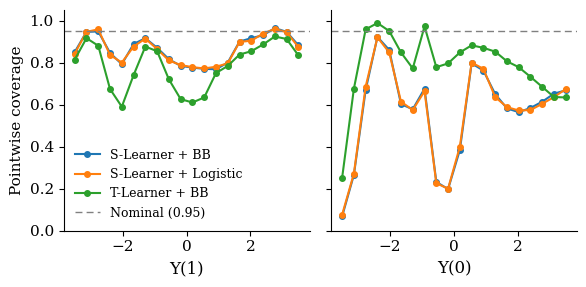

In [41]:
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

colors = {
    "S-Learner + BB":       "#1f77b4",
    "S-Learner + Logistic": "#ff7f0e",
    "T-Learner + BB":       "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

for c, (k, lab) in enumerate([("x_1", r"Y(1)"), ("x_0", r"Y(0)")]):
    ax = axes[c]
    for m in variants:
        ax.plot(y_grid_exp, coverage[m][k], marker="o", ms=4, color=colors[m], label=m)
    ax.axhline(NOMINAL, color="grey", linestyle=(0, (5, 3)), linewidth=1, label="Nominal (0.95)")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(lab, fontsize=12)

axes[0].set_ylabel("Pointwise coverage")
axes[0].legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.savefig('Figures/Simulation_Results.pdf', dpi=300, bbox_inches='tight')
plt.show()


## IV with continuous treatment

In [ ]:
def generate_iv_dgp(
    n: int = 1000,
    seed: int = 42,
    beta: float = 2.0,
    pi: float = 0.5,
    alpha: float = 1.0,
) -> dict:
    
    rng = np.random.default_rng(seed)

    Z = rng.standard_normal(n)

    # Cholesky of [[1, 0.5], [0.5, 1]]
    cov = np.array([[1.0, 0.5], [0.5, 1.0]])
    L = np.linalg.cholesky(cov)
    raw = rng.standard_normal((n, 2))
    errors = raw @ L.T          # shape (n, 2); columns are e_x, e_y

    X = pi * Z + errors[:, 0]
    Y = alpha + beta * X + errors[:, 1]

    return Y, X, Z



In [ ]:
# define parameters and simulate data
alpha, beta = 1.0, 1.0
y, x, z = generate_iv_dgp(n = 500, alpha = alpha, beta = beta, seed = 11)
T_fwd, B_post = 1500, 200

x_val = 1

# standardise y
mean_y, sd_y = np.mean(y), np.std(y)
y_std = (y - mean_y) / sd_y

y_grid = np.linspace(-2.0, 5.0, 30)
y_grid_std = (y_grid - mean_y) / sd_y

# fit martingale posteriors and compute density estimates
res = mp_density_iv(y_std, x, z, x_val, y_grid_std, B_post, T_fwd)['x_0']

# fit observational model as comparison
res_obs = mp_causal_density(y_std, x, np.ones(len(y)), y_grid_std, B_post, T_fwd, x_vals=x_val)['x_0']


In [ ]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

BLUE   = "#1f77b4"
ORANGE = "#ff7f0e"
ALPHA  = 0.18

fig, ax = plt.subplots(figsize=(6, 3.8))


true_int = norm.pdf(y_grid, loc=alpha + beta * x_val,  scale=1)
true_obs = norm.pdf(y_grid, loc=alpha + (1/2 + beta) * x_val,  scale= 1 - 3/4 * 1/4)

# ── estimated densities + credible bands ───────────────────────────────────
ax.fill_between(y_grid, res['low'] / sd_y,  res['high'] / sd_y,  color=BLUE, alpha=ALPHA)
ax.fill_between(y_grid, res_obs['low'] / sd_y, res_obs['high'] / sd_y, color=ORANGE, alpha=ALPHA)

ax.plot(y_grid, res['mean'] / sd_y,  color=BLUE,   linewidth=2)
ax.plot(y_grid, res_obs['mean'] / sd_y,  color=ORANGE,   linewidth=2)

# ── true densities (dashed) ────────────────────────────────────────────────
ax.plot(y_grid, true_int,  color=BLUE,   linewidth=1.4, linestyle=(0, (5, 3)))
ax.plot(y_grid, true_obs,  color=ORANGE,   linewidth=1.4, linestyle=(0, (5, 3)))

# ── legend: estimated curves only + single "true" entry ───────────────────
legend_handles = [
    mpatches.Patch(color=BLUE,   label=r"$Y(1)$"),
    mpatches.Patch(color=ORANGE, label=r"$Y \mid X = 1$"),
    Line2D([0], [0], color="grey", linewidth=1.4,
           linestyle=(0, (5, 3)), label="True density"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10)

# ── axes labels & layout ───────────────────────────────────────────────────
ax.set_xlabel(r"$Y$",       fontsize=12)
ax.set_ylabel("Density",    fontsize=12)
ax.set_xlim(y_grid[0], y_grid[-1])
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=10)

fig.tight_layout()
plt.savefig('Figures/IV_Simulation.pdf', dpi=300, bbox_inches='tight')
plt.show()
